In [1]:
# create our dataframe
import pandas as pd

x = [1, 2, 3, 4]
y = [6, 7, 10, 15]

data = {'x': x, 'y': y}
df = pd.DataFrame(data)

/Users/itzjuztmya/miniconda3/envs/school/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


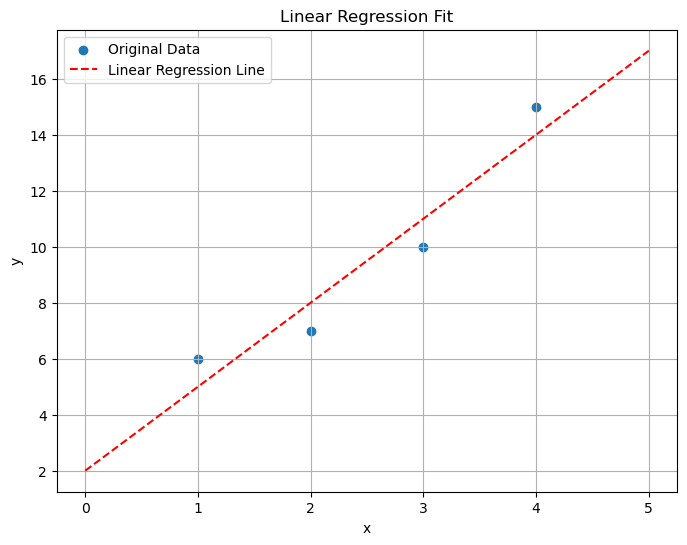

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Create a linear regression model
model = LinearRegression()

# Fit the model to the data
model.fit(df[['x']], df['y'])

# Generate x-values for the regression line to predict
x_pred = np.linspace(0, 5, 500).reshape(-1, 1)

# the trained model (model was trained on the full df_heart_disease)
y_pred = model.predict(x_pred)

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(df['x'], df['y'], label='Original Data')

# Plot the regression line
plt.plot(x_pred, y_pred, color='red', linestyle='--', label='Linear Regression Line')

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [3]:
# define loss function
def calculate_loss(x, y, w, b):
    return 0.5 * ((y - (w * x + b)) ** 2)

In [4]:
# define cost function
def calculate_cost(df, w, b):
    total_cost = 0
    for _ , row in df.iterrows():
        total_cost += calculate_loss(row['x'], row['y'], w, b)
    return total_cost / len(df)

In [5]:
# define gradient functions
def calculate_gradient_w(df, w, b):
    dJ_dw = 0
    for _ , row in df.iterrows():
        dJ_dw += (w * row['x'] + b - row['y']) * row['x']
    return dJ_dw / len(df)

def calculate_gradient_b(df, w, b):
    dJ_db = 0
    for _ , row in df.iterrows():
        dJ_db += (w * row['x'] + b - row['y'])
    return dJ_db / len(df)

In [9]:
# plot cost against parameter values to observe how gradient descent is finding the optimal values
def plot_cost_against_parameters(w_vals, b_vals, cost_vals):
  plt.figure(figsize=(12, 5))

  # Subplot 1: Cost vs. w
  plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
  plt.plot(w_vals, cost_vals, color='navy')
  plt.scatter(w_vals, cost_vals, color='gold', s=12)
  plt.xlabel('w values')
  plt.ylabel('Cost')
  plt.title('Cost vs. w')
  plt.grid(True)

  # Subplot 2: Cost vs. b
  plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
  plt.plot(b_vals, cost_vals, color='navy')
  plt.scatter(b_vals, cost_vals, color='gold', s=12)
  plt.xlabel('b values')
  plt.ylabel('Cost')
  plt.title('Cost vs. b')
  plt.grid(True)

  plt.tight_layout()
  plt.show()

1: w = 1, b = 1, Cost = 21.0
2: w = 1.875, b = 1.3, Cost = 7.4598
3: w = 2.3844, b = 1.4756, Cost = 2.8658
4: w = 2.6808, b = 1.5788, Cost = 1.307
5: w = 2.8531, b = 1.6398, Cost = 0.778
6: w = 2.9532, b = 1.6761, Cost = 0.5985
7: w = 3.0113, b = 1.6982, Cost = 0.5375
8: w = 3.0448, b = 1.7119, Cost = 0.5168
9: w = 3.064, b = 1.7207, Cost = 0.5097
10: w = 3.0749, b = 1.7266, Cost = 0.5072
11: w = 3.081, b = 1.7309, Cost = 0.5063
12: w = 3.0843, b = 1.7343, Cost = 0.506
13: w = 3.0859, b = 1.737, Cost = 0.5058
14: w = 3.0865, b = 1.7394, Cost = 0.5057
15: w = 3.0867, b = 1.7416, Cost = 0.5056
16: w = 3.0865, b = 1.7437, Cost = 0.5055
17: w = 3.0861, b = 1.7457, Cost = 0.5054
18: w = 3.0856, b = 1.7477, Cost = 0.5053
19: w = 3.085, b = 1.7496, Cost = 0.5052
20: w = 3.0844, b = 1.7515, Cost = 0.5052
21: w = 3.0838, b = 1.7534, Cost = 0.5051
22: w = 3.0832, b = 1.7552, Cost = 0.505
23: w = 3.0826, b = 1.7571, Cost = 0.5049
24: w = 3.082, b = 1.7589, Cost = 0.5049
25: w = 3.0814, b = 1.7607

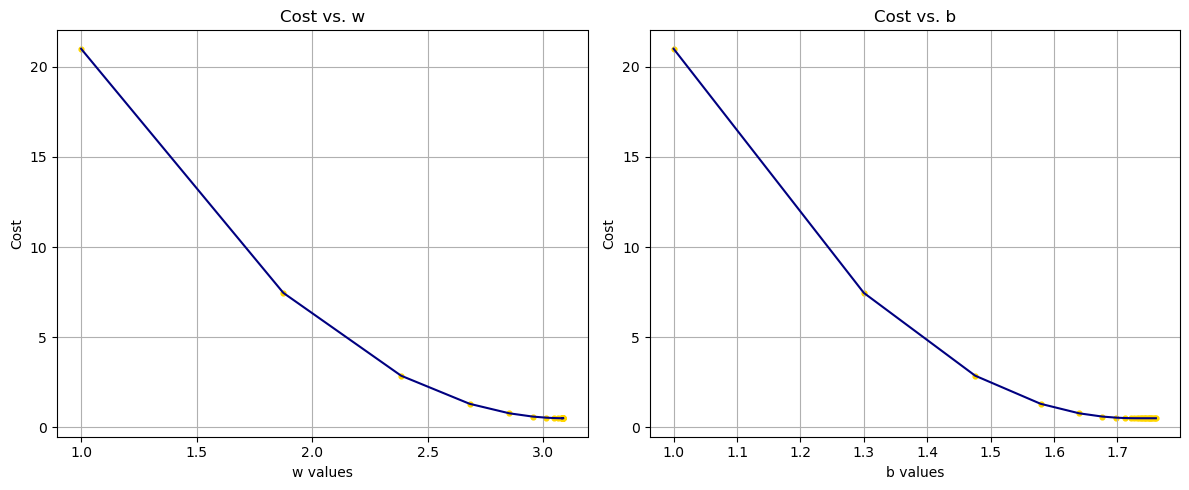

In [11]:
# initialize parameter values, learning rate, and number of steps we would like to try
w = b = 1
alpha = 0.05
n_iterations = 25

w_vals = []
b_vals = []
cost_vals = []

# run the algorithm for X steps
for i in range(n_iterations):
  current_cost = calculate_cost(df, w, b)
  current_gradient_w = calculate_gradient_w(df, w, b)
  current_gradient_b = calculate_gradient_b(df, w, b)

  # save the values to plot later
  w_vals.append(w)
  b_vals.append(b)
  cost_vals.append(current_cost)

  # Print all values at each step of the process (comment / uncomment as you like):
  print(f"{i + 1}: w = {round(w,4)}, b = {round(b,4)}, Cost = {round(current_cost,4)}")

  # update parameters each iteration except the final one
  if i < (n_iterations-1):
    w -= alpha * current_gradient_w
    b -= alpha * current_gradient_b

print('----------------')
print(f"Final parameter values: w = {round(w,4)}, b= {round(b,4)}")
print('----------------')
print()

plot_cost_against_parameters(w_vals, b_vals, cost_vals)
